# Machine Learning 지도학습 - 분류


## ⚙️환경설정


In [160]:
from sklearn import neighbors
!pip install scikit-learn -q

In [161]:
import sklearn

sklearn.__version__

'1.9.0'

In [162]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

설정된 한글 폰트: Malgun Gothic


## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>


In [163]:
# 도미와 빙어의 길이/무게 원자료

# 도미 bream 데이터 35개
# bream_length: 도미 35마리의 길이
# bream_weight: 도미 35마리의 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 smelt 데이터 14개
# smelt_length: 빙어 14마리의 길이
# smelt_weight: 빙어 14마리의 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

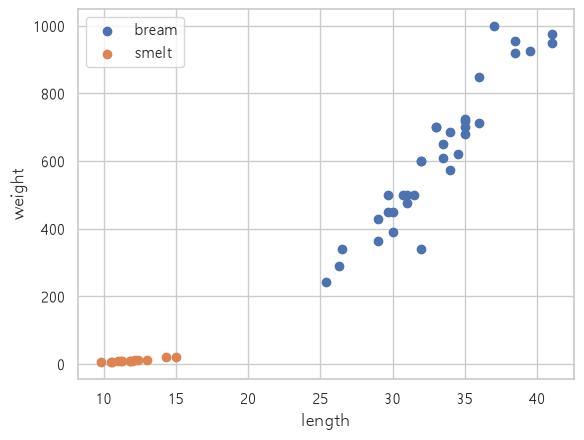

In [164]:
# 산점도

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.xlabel('length')
plt.ylabel('weight')
plt.legend(['bream', 'smelt'])
plt.show()

## KNN K-최근접이웃분류모델
데이터포인트간의 거리기반으로 분류를 수행하는 모델


### k-최근접 이웃 알고리즘 작동원리

최근접이웃(K-Nearest Neighbors, KNN)에서 거리를 구하는 방법으로 가장 일반적으로 사용되는 방법은 **유클리드 거리(Euclidean distance)**이다.

유클리드 거리란 "두 점 사이의 직선 거리" 를 구하는 가장 간단한 방법이다.

좌표상 (0, 0)과 (3, 4)라는 점 두 개를 찍었다고 하자. 이 두 점을 선으로 연결하면, 바로 그 선의 길이가 유클리드 거리이다!

$$\text { 거리 }=\sqrt{\left(x_{2}-x_{1}\right)^{2}+\left(y_{2}-y_{1}\right)^{2}}$$

두 점 $p = (p_1, p_2, ..., p_n)$과 $q = (q_1, q_2, ..., q_n)$ 사이의 유클리드 거리는 다음과 같은 수식으로 계산된다.

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}$$

#### 다양한 거리계산법
이 외에도 거리 계산에 사용하는 방법에는 **맨해튼 거리(Manhattan distance)**, **민코프스키 거리(Minkowski distance)**, **코사인 유사도(Cosine similarity)** 등이 있다.

1. 맨해튼 거리 계산식:

$$d(p, q) = |p_1 - q_1| + |p_2 - q_2| + \cdots + |p_n - q_n|$$

2. 민코프스키 거리 계산식(유클리드와 맨해튼 거리를 일반화한 형태):
  (여기서 $p = 2$일 때는 유클리드 거리, $p = 1$일 때는 맨해튼 거리이다)
$$d(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{1/p}$$

3. 코사인 유사도:
  (여기서 $p \cdot q$는 두 벡터의 내적, $\|p\|$와 $\|q\|$는 벡터의 크기이다)
$$\cos \theta = \frac{p \cdot q}{\|p\| \|q\|}$$



In [165]:
# 데이터 변환 변수로, 이어 붙이기
fish_length = bream_length + smelt_length
fish_weight = bream_weight + smelt_weight

fish_data = [[length, weight] for length, weight in zip(fish_length, fish_weight)]
fish_data = np.array(fish_data)
print(fish_data)

[[  25.4  242. ]
 [  26.3  290. ]
 [  26.5  340. ]
 [  29.   363. ]
 [  29.   430. ]
 [  29.7  450. ]
 [  29.7  500. ]
 [  30.   390. ]
 [  30.   450. ]
 [  30.7  500. ]
 [  31.   475. ]
 [  31.   500. ]
 [  31.5  500. ]
 [  32.   340. ]
 [  32.   600. ]
 [  32.   600. ]
 [  33.   700. ]
 [  33.   700. ]
 [  33.5  610. ]
 [  33.5  650. ]
 [  34.   575. ]
 [  34.   685. ]
 [  34.5  620. ]
 [  35.   680. ]
 [  35.   700. ]
 [  35.   725. ]
 [  35.   720. ]
 [  36.   714. ]
 [  36.   850. ]
 [  37.  1000. ]
 [  38.5  920. ]
 [  38.5  955. ]
 [  39.5  925. ]
 [  41.   975. ]
 [  41.   950. ]
 [   9.8    6.7]
 [  10.5    7.5]
 [  10.6    7. ]
 [  11.     9.7]
 [  11.2    9.8]
 [  11.3    8.7]
 [  11.8   10. ]
 [  11.8    9.9]
 [  12.     9.8]
 [  12.2   12.2]
 [  12.4   13.4]
 [  13.    12.2]
 [  14.3   19.7]
 [  15.    19.9]]


In [166]:
# fish label 생성

# domi = 1
# bing = 0

fish_target = np.array([1]* 35 + [0] * 14)
print(fish_target)


[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0]


In [167]:
# knc - 근접 데이터의 라벨 선택

from sklearn.neighbors import KNeighborsClassifier

kn_clf = KNeighborsClassifier(n_neighbors=5)

kn_clf.get_params()



{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

| 항목 | 의미 |
|---|---|
| `n_neighbors = 5` | 가장 가까운 이웃 5개를 보고 판단 |
| `weights = 'uniform'` | 이웃 5개의 투표 가중치를 똑같이 적용 |
| `algorithm = 'auto'` | 가까운 이웃을 찾는 방법은 scikit-learn이 자동 선택 |
| `p = 2` | 거리 계산에서 유클리드 거리 사용 |
| `metric = 'minkowski'` | 민코프스키 거리 사용, `p=2`라서 사실상 유클리드 거리 |
| `n_jobs = None` | 병렬 처리 별도 지정 안 함 |

| 항목 | 의미 |
|---|---|
| `classes_ = [0, 1]` | 이 모델이 배운 정답 종류는 0과 1 |
| `n_features_in_ = 2` | 입력 feature는 2개, 즉 길이와 무게 |
| `n_samples_fit_ = 49` | 학습에 사용한 생선 데이터는 49개 |
| `outputs_2d_ = False` | 정답 `y`가 2차원이 아니라 1차원이라는 뜻 |

In [168]:
# 학습용 데이터

kn_clf.fit(fish_data, fish_target)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

KNeighborsClassifier()

In [169]:
kn_clf.score(fish_data, fish_target)

1.0

In [170]:
# 새 다타

#predict - 입력은 2차원으로

smp = [[15, 100],[45,500]]

kn_clf.predict(smp)

array([0, 1])

In [171]:
# 새 다타와 가장 가까운 이웃 내놔

distances, indices = kn_clf.kneighbors([[15, 30]], n_neighbors=5)

distances # 새 다타와 가까운 이웃간의 거리

indices # 이웃의 인덱스 번호

print(fish_target.shape)
print(indices)
print(indices.shape)
print(indices.max())

(49,)
[[48 47 45 46 44]]
(1, 5)
48


In [172]:
print(fish_target[indices])

[[0 0 0 0 0]]


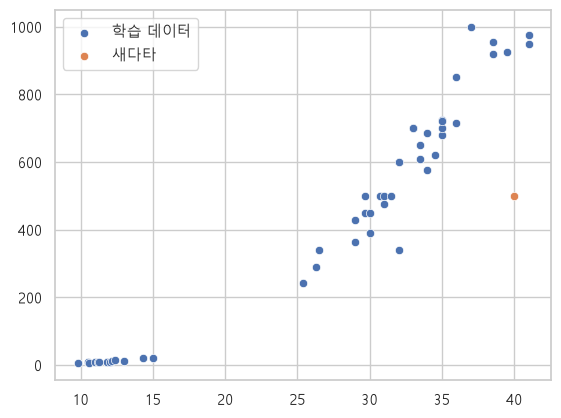

In [173]:
sns.scatterplot(x=fish_data[:, 0], y=fish_data[:,1], label = '학습 데이터')

sns.scatterplot(x = [40], y = [500], label = '새다타')


plt.show()

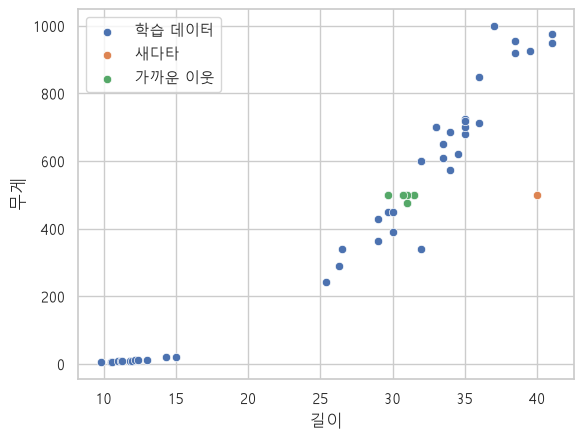

In [174]:

distances, indices = kn_clf.kneighbors([[40, 500]], n_neighbors=5)

# print(indices.squeeze())
sns.scatterplot(x=fish_data[:, 0], y=fish_data[:,1], label = '학습 데이터')

sns.scatterplot(x = [40], y = [500], label = '새다타')

neighbor_indices = indices.squeeze()

sns.scatterplot( x = fish_data[neighbor_indices, 0],  y = fish_data[neighbor_indices, 1], label = '가까운 이웃')

plt.xlabel('길이')
plt.ylabel('무게')
plt.show()


## 학습/테스트 세트 분리


In [175]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(fish_data, fish_target, test_size=0.2, stratify=fish_target)

print(X_train.shape)
print(y_train)
print(X_test.shape)
print(y_test.shape)


(39, 2)
[1 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 1 1 1 1
 1 0]
(10, 2)
(10,)


In [176]:
kn_clf = KNeighborsClassifier(n_neighbors=5)
kn_clf.fit(X_train, y_train)
kn_clf.score(X_test, y_test)
# knc.predict(X_test)

1.0

## 수상한 도미
도미(길이 25, 무게 150)의 문제


In [177]:
mystery = [25, 150]
kn_clf.predict([mystery]) # == 빙어래요 빙어래요~빙어래요~ 망했데요~

array([0])

[[ 92.00086956 130.48375378 138.32150953 138.39320793 140.00603558]] [[12 22 23 13 33]]
[[1 0 0 0 1]]


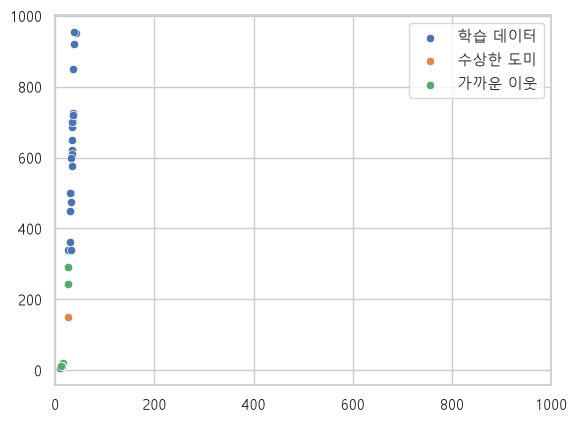

In [178]:
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], label='학습 데이터')
sns.scatterplot(x=[25], y=[150], label='수상한 도미')

distances, indices = kn_clf.kneighbors([[25, 150]])
print(distances, indices)

print(y_train[indices])

neighbor_indices = indices.squeeze()

sns.scatterplot(
    x=X_train[neighbor_indices, 0],
    y=X_train[neighbor_indices, 1],
    label='가까운 이웃',
)

plt.xlim((0, 1000))
plt.legend()
plt.show()

## 표준점수-스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리기법.
모델 성능에 직접적인 영향이 있음.


###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.


In [180]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
# 스케일링 후 fit 할 시 더해지는 경우가 생김

# 재 학습

kn_clf = KNeighborsClassifier(n_neighbors=5)
kn_clf.fit(X_train_scaled, y_train)
kn_clf.score(X_test_scaled, y_test)



1.0

In [183]:
# mystery 스케일링 후 예측

q = scaler.transform([mystery])
print(q)
kn_clf.predict(q)

[[-0.26809708 -0.91408422]]


array([1])

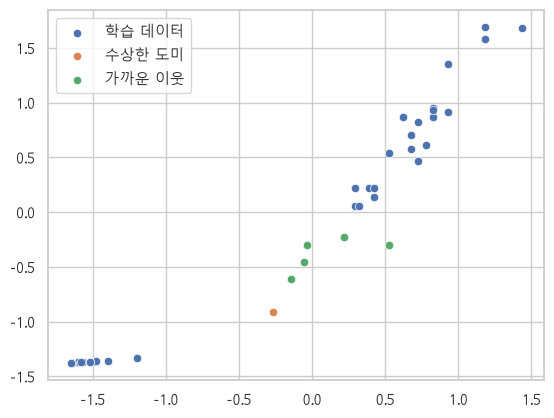

In [184]:
# X_train_scaled[:, 0]: 스케일링된 길이
# X_train_scaled[:, 1]: 스케일링된 무게
sns.scatterplot(x=X_train_scaled[:, 0], y=X_train_scaled[:, 1], label='학습 데이터')

sns.scatterplot(x=q[:, 0], y=q[:, 1], label='수상한 도미')

distances, indices = kn_clf.kneighbors(q)
neighbor_indices = indices.squeeze()

sns.scatterplot(
    x=X_train_scaled[neighbor_indices, 0],
    y=X_train_scaled[neighbor_indices, 1],
    label='가까운 이웃',
)

plt.legend()
plt.show()

# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.



In [198]:
data = pd.read_csv('./data/fish.csv')

# data.head()



0    Bream
1    Bream
2    Bream
3    Bream
4    Bream
5    Bream
6    Bream
7    Bream
8    Bream
9    Bream
Name: Species, dtype: str

In [213]:
# X, y

X = data.iloc[:, 1:].to_numpy()
print(X)
print(type(X))
y = data.iloc[:, 0].to_numpy()
print(y)
# y.head(10)

[[2.42000e+02 2.54000e+01 3.00000e+01 1.15200e+01 4.02000e+00]
 [2.90000e+02 2.63000e+01 3.12000e+01 1.24800e+01 4.30560e+00]
 [3.40000e+02 2.65000e+01 3.11000e+01 1.23778e+01 4.69610e+00]
 [3.63000e+02 2.90000e+01 3.35000e+01 1.27300e+01 4.45550e+00]
 [4.30000e+02 2.90000e+01 3.40000e+01 1.24440e+01 5.13400e+00]
 [4.50000e+02 2.97000e+01 3.47000e+01 1.36024e+01 4.92740e+00]
 [5.00000e+02 2.97000e+01 3.45000e+01 1.41795e+01 5.27850e+00]
 [3.90000e+02 3.00000e+01 3.50000e+01 1.26700e+01 4.69000e+00]
 [4.50000e+02 3.00000e+01 3.51000e+01 1.40049e+01 4.84380e+00]
 [5.00000e+02 3.07000e+01 3.62000e+01 1.42266e+01 4.95940e+00]
 [4.75000e+02 3.10000e+01 3.62000e+01 1.42628e+01 5.10420e+00]
 [5.00000e+02 3.10000e+01 3.62000e+01 1.43714e+01 4.81460e+00]
 [5.00000e+02 3.15000e+01 3.64000e+01 1.37592e+01 4.36800e+00]
 [3.40000e+02 3.20000e+01 3.73000e+01 1.39129e+01 5.07280e+00]
 [6.00000e+02 3.20000e+01 3.72000e+01 1.49544e+01 5.17080e+00]
 [6.00000e+02 3.20000e+01 3.72000e+01 1.54380e+01 5.580

<Axes: xlabel='Length', ylabel='Weight'>

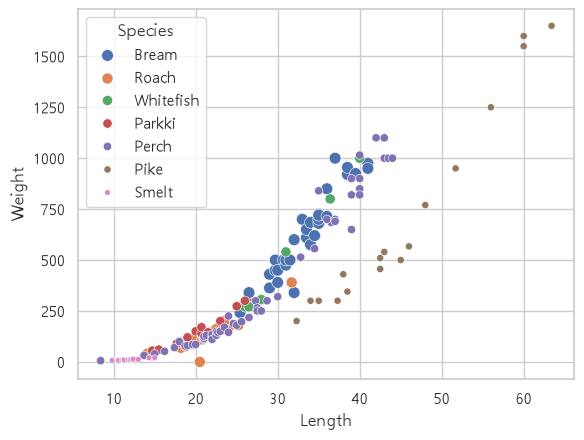

In [214]:
sns.scatterplot(
    data=data,
    x='Length',
    y='Weight',
    hue='Species',
    size='Species'
)

In [217]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [224]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kn_clf = KNeighborsClassifier(n_neighbors=3)

kn_clf.fit(X_train_scaled, y_train)

print(kn_clf.score(X_train_scaled, y_train))
print(kn_clf.score(X_test_scaled, y_test))


0.889763779527559
0.8125


In [225]:
kn_clf.__dict__

{'n_neighbors': 3,
 'radius': None,
 'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'p': 2,
 'n_jobs': None,
 'weights': 'uniform',
 'n_features_in_': 5,
 'outputs_2d_': False,
 'classes_': array(['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish'],
       dtype=object),
 '_y': array([1, 5, 2, 0, 0, 0, 0, 2, 2, 2, 4, 4, 0, 3, 2, 0, 2, 1, 4, 2, 2, 3,
        2, 2, 2, 0, 0, 2, 4, 0, 5, 2, 4, 0, 2, 0, 5, 2, 5, 5, 0, 6, 1, 0,
        2, 1, 3, 2, 3, 1, 0, 2, 2, 0, 5, 1, 2, 0, 4, 2, 0, 2, 4, 0, 2, 2,
        6, 3, 2, 2, 0, 4, 2, 5, 3, 3, 2, 4, 0, 2, 0, 3, 2, 3, 2, 1, 6, 2,
        0, 5, 2, 1, 4, 0, 4, 2, 2, 0, 2, 4, 0, 0, 4, 4, 4, 3, 3, 2, 5, 1,
        3, 2, 4, 6, 6, 0, 5, 2, 2, 2, 2, 2, 0, 3, 5, 2, 2]),
 'effective_metric_params_': {},
 'effective_metric_': 'euclidean',
 '_fit_method': 'kd_tree',
 '_fit_X': array([[-5.79927544e-01, -5.27828558e-01, -4.87545368e-01,
          3.09900763e-01, -4.66326256e-01],
        [-1.14865496e+00, 

In [226]:
print(X_test_scaled.shape)


(32, 5)


In [229]:
print(X_test_scaled[:5])

[[1.36367298 0.74379693 0.94043381 1.84940798 1.05408739]]


In [233]:
# 다중 분휴에서 kneighbor()로 예측 근거가 된 이유 찾기
distances, indices = kn_clf.kneighbors(X_test_scaled[:1])

print(X_test_scaled[0])
print(distances)
print(indices)

print(y_train[indices])

[1.36367298 0.74379693 0.94043381 1.84940798 1.05408739]
[[0.43414966 0.46522533 0.48136003]]
[[101  50  26]]
[['Bream' 'Bream' 'Bream']]


## @실습문제: 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)


In [241]:
from sklearn.datasets import load_iris

iris = load_iris()

# print(iris)

X = iris.data
y = iris.target

# print(X)
# print(y)
print(iris.target_names)
print(iris.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [243]:
iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names,
)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [254]:
# 1. train/test split
X_train, X_test, y_train, y_test = train_test_split(
    iris.data,    # 입력 X
    iris.target,  # 정답 y
    stratify=iris.target,
    random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# 2. 스케일링
scaler = StandardScaler()
scaler.fit(X_train) # X_train기준 평균, 표준편차 학습

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 3. KNN 분류 모델 생성 + 학습 fit()
kn_clf = KNeighborsClassifier(n_neighbors=3)
kn_clf.fit(X_train_scaled, y_train)

# 4. 평가  score()
print("학습 데이터셋 평가 : ", kn_clf.score(X_train_scaled, y_train))
print("테이스 데이터셋 평가 : ", kn_clf.score(X_test_scaled, y_test))

# 5. 예측 predict() - test 데이터 일부와, 실제 정답을 비교
print("예측: ", kn_clf.predict(X_test_scaled[:5]))
print("정답: ", y_test[:5])

(112, 4) (112,)
(38, 4) (38,)
학습 데이터셋 평가 :  0.9642857142857143
테이스 데이터셋 평가 :  0.9210526315789473
예측:  [0 1 1 1 0]
정답:  [0 1 1 1 0]
